In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *


IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 335119


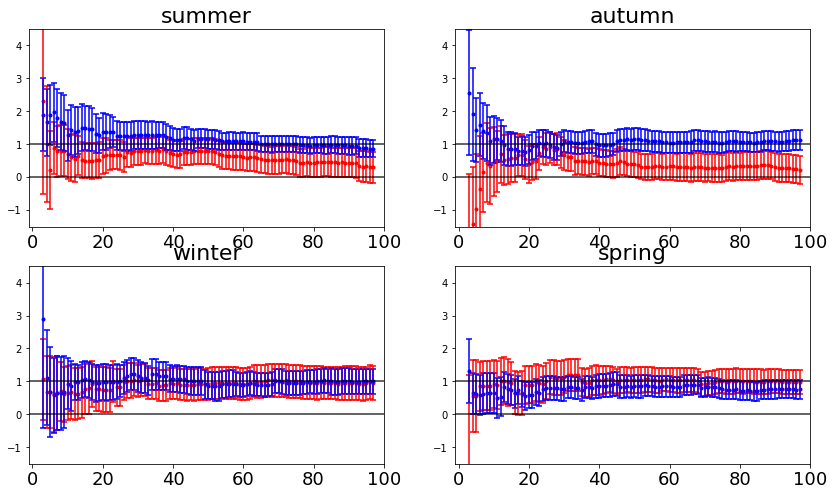

In [10]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

fig,axs = plt.subplots(2,2,figsize=(14,8))
axs = axs.flatten()

for i,season in enumerate(['summer','autumn','winter','spring']):
    
    plot_saved_result(axs[i],season,'1969','2019',font)

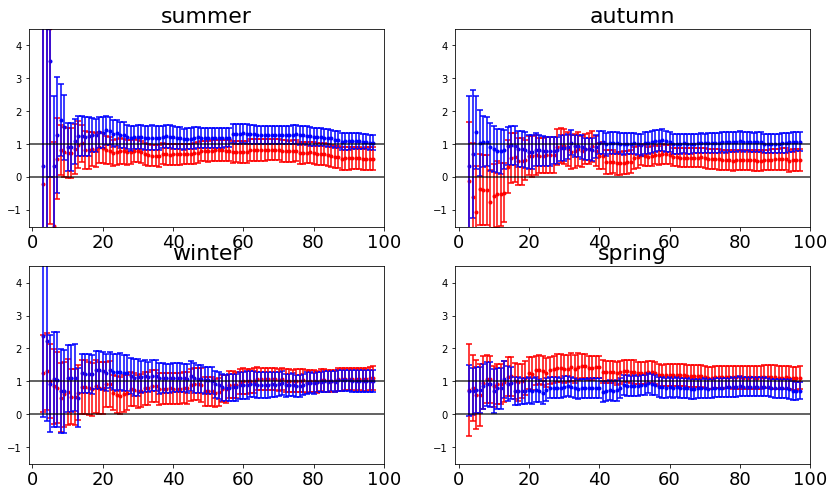

In [8]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

fig,axs = plt.subplots(2,2,figsize=(14,8))
axs = axs.flatten()

for i,season in enumerate(['summer','autumn','winter','spring']):
    
    plot_saved_result(axs[i],season,'1951','2020',font)

In [2]:
def plot_saved_result(ax,season,start,end,font):

    df = pd.read_csv('hydro_attribution/result_files/d4PDF_TA_obs_'+season+'_'+start+'_'+end+'.csv')
    
    ax.scatter(df['Truncation'],df['ant_best'],color='red',marker='.',label='ANT')
    ax.scatter(df['Truncation'],df['ant_upper'],color='red',marker='_')
    ax.scatter(df['Truncation'],df['ant_lower'],color='red',marker='_')
    ax.vlines(df['Truncation'],df['ant_lower'],df['ant_upper'],color='red')

    ax.scatter(df['Truncation'],df['nat_best'],color='blue',marker='.',label='NAT')
    ax.scatter(df['Truncation'],df['nat_upper'],color='blue',marker='_')
    ax.scatter(df['Truncation'],df['nat_lower'],color='blue',marker='_')
    ax.vlines(df['Truncation'],df['nat_lower'],df['nat_upper'],color='blue')

    ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
    ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
    ax.set_ylim(-1.5,4.5)
    
    font['size'] = 18
    
    ax.set_xlim(-1,100)
    ax.set_xticks([20*i for i in range(6)])
    ax.set_xticklabels([str(20*i) for i in range(6)],fontdict=font)
    
    font['size'] = 22
    
    ax.set_title(season,fontdict=font)
    
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    
    #plt.close(fig)
    

getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec
getting obs
getting ALL mean and noise
getting NAT mean and noise
got arrays
running gendetec


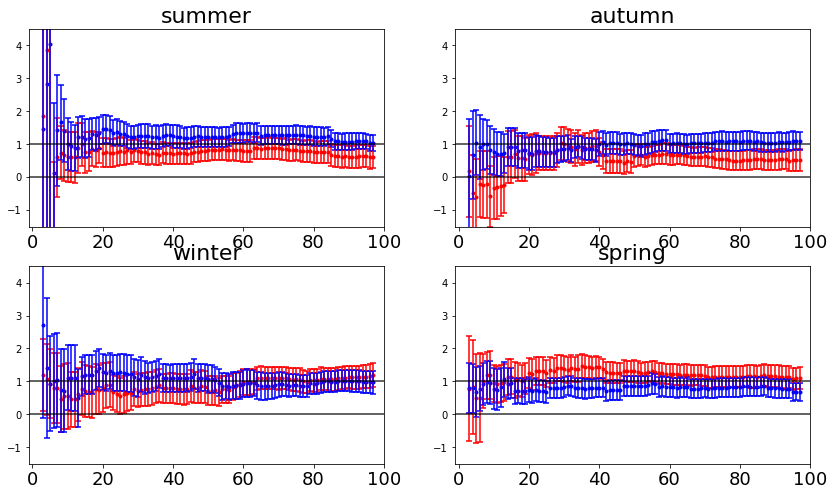

In [18]:
'''
MAIN function for performing optimal fingerprinting
'''

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

start = 1951
end = 2020

fig,axs = plt.subplots(2,2,figsize=(14,8))
axs = axs.flatten() 

for i,season in enumerate(['summer','autumn','winter','spring']):
    
    IDL.retall

    data_obs,all_ens_mean,noise_all,nat_ens_mean,noise_nat = get_all_data(season,start,end)

    data_scen = np.array([all_ens_mean,nat_ens_mean])
    data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
    data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))

    print('got arrays')

    trunc = np.array([i for i in range(3,98)])

    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []


    print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid")

    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid


    #save_result(scan_beta_est,trunc,season,start,end)
    plot_result(axs[i],scan_beta_est,trunc)


In [6]:
print(all_ens_mean.shape)
print(nat_ens_mean.shape)
print(data_obs.shape)
print(data_scen.shape)
print(data_noise_1.shape)
print(data_noise_2.shape)

(850,)
(850,)
(850,)
(2, 850)
(100, 900)
(100, 900)


In [11]:
def get_all_data(season, start, end):
    
    print('getting obs')
    data_obs,missing_indices = get_obs_data(season,start,end)
    
    print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(missing_indices,'HPB',season,start,end)
    
    print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(missing_indices,'HPB_NAT',season,start,end)

    return(data_obs,all_ens_mean,noise_all,nat_ens_mean,noise_nat)

In [16]:
def get_obs_data(season,start,end):
    
    obs_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/temperature/temp_obs_'+season+'_gaussian.csv')
    obs_df = obs_df.set_index('date')
    obs_df = obs_df[str(start):str(end+1)]
    
    obs_array = obs_df.values.flatten()

    # find indices of nan values
    missing_indices = np.argwhere(np.isnan(obs_array))
    
    # remove nan values
    obs_array = np.delete(obs_array,missing_indices)
    
    return(obs_array,missing_indices)

def get_noise(missing_indices,scen,season,mean_array,start,end):
    
    noise = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        
        mem_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/TA/full/station_resolution/TA_d4PDF_'+scen+'_m'+number+'_gaussian_'+season+'_1951-2021.csv')
        mem_df = mem_df.set_index('time').drop('Unnamed: 0',axis=1)
        mem_df = mem_df[str(start):str(end+1)]
        mem_array = mem_df.values.flatten()
                
        # remove elements where observations were missing
        mem_array = np.delete(mem_array,missing_indices)
        
        diff_array = mem_array - mean_array
        
        noise.append(diff_array)
        
    return(noise)

def get_mean_and_noise(missing_indices,scen,season,start,end):
    
    mean_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/TA/full/station_resolution/TA_d4PDF_'+scen+'_ensMean_gaussian_'+season+'_1951-2021.csv')
    mean_df = mean_df.set_index('time')
    mean_df = mean_df[str(start):str(end+1)]
    mean_array = mean_df.values.flatten()
    
    # remove elements where observations were missing
    mean_array = np.delete(mean_array,missing_indices)
        
    noise = get_noise(missing_indices,scen,season,mean_array,start,end)
    
    return((mean_array, np.array(noise)))


In [13]:
def save_result(scan_beta_est,trunc,season,start,end):

    df_dict = {'Truncation':trunc,'ant_best':[],'ant_lower':[],'ant_upper':[],'nat_best':[],'nat_lower':[],'nat_upper':[]}
    
    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]

        df_dict['ant_best'].append(beta_est[0][0])
        df_dict['ant_lower'].append(beta_est[1][0])
        df_dict['ant_upper'].append(beta_est[2][0])
        
        df_dict['nat_best'].append(beta_est[0][1])
        df_dict['nat_lower'].append(beta_est[1][1])
        df_dict['nat_upper'].append(beta_est[2][1])
        
    df = pd.DataFrame.from_dict(df_dict)
    
    df.to_csv('hydro_attribution/result_files/d4PDF_TA_obs_'+season+'_'+start+'_'+end+'.csv')
    

In [14]:
def plot_result(ax,scan_beta_est,trunc):
    
    df_dict = {'Truncation':trunc,'ant_best':[],'ant_lower':[],'ant_upper':[],'nat_best':[],'nat_lower':[],'nat_upper':[]}
    
    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]

        df_dict['ant_best'].append(beta_est[0][0])
        df_dict['ant_lower'].append(beta_est[1][0])
        df_dict['ant_upper'].append(beta_est[2][0])
        
        df_dict['nat_best'].append(beta_est[0][1])
        df_dict['nat_lower'].append(beta_est[1][1])
        df_dict['nat_upper'].append(beta_est[2][1])
        
    df = pd.DataFrame.from_dict(df_dict)
        
    ax.scatter(df['Truncation'],df['ant_best'],color='red',marker='.',label='ANT')
    ax.scatter(df['Truncation'],df['ant_upper'],color='red',marker='_')
    ax.scatter(df['Truncation'],df['ant_lower'],color='red',marker='_')
    ax.vlines(df['Truncation'],df['ant_lower'],df['ant_upper'],color='red')

    ax.scatter(df['Truncation'],df['nat_best'],color='blue',marker='.',label='NAT')
    ax.scatter(df['Truncation'],df['nat_upper'],color='blue',marker='_')
    ax.scatter(df['Truncation'],df['nat_lower'],color='blue',marker='_')
    ax.vlines(df['Truncation'],df['nat_lower'],df['nat_upper'],color='blue')

    ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
    ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
    ax.set_ylim(-1.5,4.5)
    
    font['size'] = 18
    
    ax.set_xlim(-1,100)
    ax.set_xticks([20*i for i in range(6)])
    ax.set_xticklabels([str(20*i) for i in range(6)],fontdict=font)
    
    font['size'] = 22
    
    ax.set_title(season,fontdict=font)
